# Read Database

In [66]:
import pandas as pd
import sqlite3
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

labelencoder = LabelEncoder()

conn = sqlite3.connect('bmarket.db') 

sql_query = "SELECT * FROM bank_marketing"

df = pd.read_sql(sql_query, conn)

conn.close()

df.head()


,Client ID,Age,Occupation,Marital Status,Education Level,Credit Default,Housing Loan,Personal Loan,Contact Method,Campaign Calls,Previous Contact Days,Subscription Status
0,32885,57 years,technician,married,high.school,no,no,yes,Cell,1,999,no
1,3170,55 years,unknown,married,unknown,unknown,yes,no,telephone,2,999,no
2,32207,33 years,blue-collar,married,basic.9y,no,no,no,cellular,1,999,no
3,9404,36 years,admin.,married,high.school,no,no,no,Telephone,4,999,no
4,14021,27 years,housemaid,married,high.school,no,None,no,Cell,2,999,no


In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Client ID              41188 non-null  int64 
 1   Age                    41188 non-null  object
 2   Occupation             41188 non-null  object
 3   Marital Status         41188 non-null  object
 4   Education Level        41188 non-null  object
 5   Credit Default         41188 non-null  object
 6   Housing Loan           16399 non-null  object
 7   Personal Loan          37042 non-null  object
 8   Contact Method         41188 non-null  object
 9   Campaign Calls         41188 non-null  int64 
 10  Previous Contact Days  41188 non-null  int64 
 11  Subscription Status    41188 non-null  object
dtypes: int64(3), object(9)
memory usage: 3.8+ MB


# Data Cleaning

In [68]:
df_drop_dups = df.drop_duplicates()
df_drop_dups

,Client ID,Age,Occupation,Marital Status,Education Level,Credit Default,Housing Loan,Personal Loan,Contact Method,Campaign Calls,Previous Contact Days,Subscription Status
0,32885,57 years,technician,married,high.school,no,no,yes,Cell,1,999,no
1,3170,55 years,unknown,married,unknown,unknown,yes,no,telephone,2,999,no
2,32207,33 years,blue-collar,married,basic.9y,no,no,no,cellular,1,999,no
3,9404,36 years,admin.,married,high.school,no,no,no,Telephone,4,999,no
4,14021,27 years,housemaid,married,high.school,no,None,no,Cell,2,999,no
...,...,...,...,...,...,...,...,...,...,...,...,...
41183,6266,58 years,retired,married,professional.course,unknown,no,no,Telephone,2,999,no
41184,11285,37 years,management,married,university.degree,no,no,no,telephone,1,999,no
41185,38159,35 years,admin.,married,high.school,no,None,no,cellular,1,4,yes
41186,861,40 years,management,married,university.degree,no,None,no,telephone,2,999,no


Explain that there is no duplicates

In [69]:
print(list(df_drop_dups.columns))

for tag in list(df_drop_dups.columns):
    print(f"\n {tag}: {df_drop_dups[tag].unique()}")

['Client ID', 'Age', 'Occupation', 'Marital Status', 'Education Level', 'Credit Default', 'Housing Loan', 'Personal Loan', 'Contact Method', 'Campaign Calls', 'Previous Contact Days', 'Subscription Status']

 Client ID: [32885  3170 32207 ... 38159   861 15796]

 Age: ['57 years' '55 years' '33 years' '36 years' '27 years' '58 years'
 '48 years' '150 years' '24 years' '34 years' '42 years' '43 years'
 '26 years' '37 years' '46 years' '59 years' '49 years' '30 years'
 '51 years' '45 years' '31 years' '41 years' '38 years' '47 years'
 '69 years' '50 years' '25 years' '39 years' '44 years' '52 years'
 '35 years' '77 years' '40 years' '56 years' '53 years' '60 years'
 '29 years' '28 years' '54 years' '32 years' '81 years' '63 years'
 '21 years' '22 years' '74 years' '80 years' '62 years' '68 years'
 '86 years' '23 years' '71 years' '67 years' '65 years' '20 years'
 '19 years' '66 years' '75 years' '18 years' '72 years' '70 years'
 '82 years' '85 years' '61 years' '88 years' '83 years' '78 

This is to check the type of tags within the information

In [70]:
df_drop_dups["Age"] = df_drop_dups["Age"].apply(lambda x: int(x.split()[0]))
df_drop_dups

,Client ID,Age,Occupation,Marital Status,Education Level,Credit Default,Housing Loan,Personal Loan,Contact Method,Campaign Calls,Previous Contact Days,Subscription Status
0,32885,57,technician,married,high.school,no,no,yes,Cell,1,999,no
1,3170,55,unknown,married,unknown,unknown,yes,no,telephone,2,999,no
2,32207,33,blue-collar,married,basic.9y,no,no,no,cellular,1,999,no
3,9404,36,admin.,married,high.school,no,no,no,Telephone,4,999,no
4,14021,27,housemaid,married,high.school,no,None,no,Cell,2,999,no
...,...,...,...,...,...,...,...,...,...,...,...,...
41183,6266,58,retired,married,professional.course,unknown,no,no,Telephone,2,999,no
41184,11285,37,management,married,university.degree,no,no,no,telephone,1,999,no
41185,38159,35,admin.,married,high.school,no,None,no,cellular,1,4,yes
41186,861,40,management,married,university.degree,no,None,no,telephone,2,999,no


In [71]:
df_drop_dups['Contact Method'] = df_drop_dups['Contact Method'].str.lower().str.strip()

df_drop_dups['Contact Method'] = df_drop_dups['Contact Method'].replace({
    'cell': 'cellular', 'Telephone': 'telephone'})

df_drop_dups['Housing Loan'] = df_drop_dups['Housing Loan'].replace({ None: "unknown" })

df_drop_dups['Personal Loan'] = df_drop_dups['Personal Loan'].replace({ None: "unknown" })

In [72]:
df_drop_dups['Contact Method'].value_counts()

Contact Method
cellular     26144
telephone    15044
Name: count, dtype: int64

In [73]:
df_drop_dups["Credit Default"].value_counts()

Credit Default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64

In [74]:
df_drop_dups['Personal Loan'].value_counts()

Personal Loan
no         30532
yes         5633
unknown     5023
Name: count, dtype: int64

In [75]:
df_drop_dups["Housing Loan"].value_counts()

Housing Loan
unknown    25182
yes         8595
no          7411
Name: count, dtype: int64

In [76]:
df_copy = df_drop_dups
df_copy['Subscription Status'] = df_copy['Subscription Status'].replace({ "no" : 0, "yes": 1 })

df_negative_calls = df_copy[df_copy["Campaign Calls"] < 0]
df_positive_calls = df_copy[df_copy["Campaign Calls"] >= 0]

C:\Users\Qxiuj\AppData\Local\Temp\ipykernel_28332\2927662062.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_copy['Subscription Status'] = df_copy['Subscription Status'].replace({ "no" : 0, "yes": 1 })


In [77]:
df_negative_calls.drop(columns=["Client ID", "Age"], inplace=True)
df_positive_calls.drop(columns=["Client ID", "Age"], inplace=True)

C:\Users\Qxiuj\AppData\Local\Temp\ipykernel_28332\1864044228.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_negative_calls.drop(columns=["Client ID", "Age"], inplace=True)
C:\Users\Qxiuj\AppData\Local\Temp\ipykernel_28332\1864044228.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_positive_calls.drop(columns=["Client ID", "Age"], inplace=True)


C:\Users\Qxiuj\AppData\Local\Temp\ipykernel_28332\3325005599.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


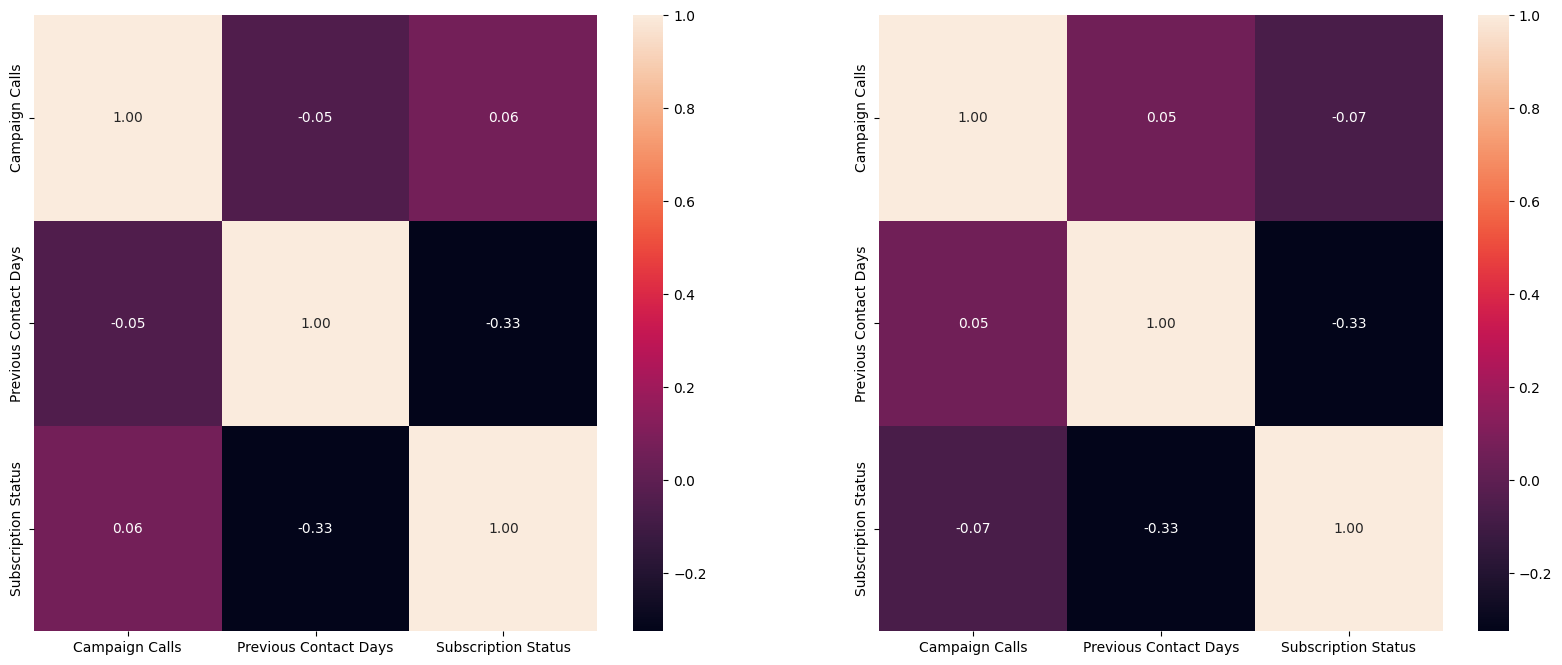

In [78]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1,2 , figsize=(20, 8))
sns.heatmap(df_negative_calls.corr(numeric_only=True), annot=True, fmt=".2f", ax=ax[0])
sns.heatmap(df_positive_calls.corr(numeric_only=True), annot=True, fmt=".2f", ax=ax[1])
fig.show()

In [79]:
df_drop_dups["Campaign Calls"] = df_drop_dups["Campaign Calls"].abs()
df_drop_dups

,Client ID,Age,Occupation,Marital Status,Education Level,Credit Default,Housing Loan,Personal Loan,Contact Method,Campaign Calls,Previous Contact Days,Subscription Status
0,32885,57,technician,married,high.school,no,no,yes,cellular,1,999,0
1,3170,55,unknown,married,unknown,unknown,yes,no,telephone,2,999,0
2,32207,33,blue-collar,married,basic.9y,no,no,no,cellular,1,999,0
3,9404,36,admin.,married,high.school,no,no,no,telephone,4,999,0
4,14021,27,housemaid,married,high.school,no,unknown,no,cellular,2,999,0
...,...,...,...,...,...,...,...,...,...,...,...,...
41183,6266,58,retired,married,professional.course,unknown,no,no,telephone,2,999,0
41184,11285,37,management,married,university.degree,no,no,no,telephone,1,999,0
41185,38159,35,admin.,married,high.school,no,unknown,no,cellular,1,4,1
41186,861,40,management,married,university.degree,no,unknown,no,telephone,2,999,0


# Correlation Coefficient

In [80]:
str_columns = df_copy.select_dtypes(include=['object']).columns.tolist()
str_columns

['Occupation',
 'Marital Status',
 'Education Level',
 'Credit Default',
 'Housing Loan',
 'Personal Loan',
 'Contact Method']

Label encoding below

In [81]:
df_label_encoded = df_drop_dups.copy()
df_label_encoded.drop(columns=["Client ID"], inplace=True)
str_columns = df_copy.select_dtypes(include=['object']).columns.tolist()

for col in str_columns:
    df_label_encoded[col] = labelencoder.fit_transform(df_label_encoded[col])

df_label_encoded["Previous Contact Days"] = df_label_encoded["Previous Contact Days"].replace({999: 0})
df_label_encoded

,Age,Occupation,Marital Status,Education Level,Credit Default,Housing Loan,Personal Loan,Contact Method,Campaign Calls,Previous Contact Days,Subscription Status
0,57,9,1,3,0,0,2,0,1,0,0
1,55,11,1,7,1,2,0,1,2,0,0
2,33,1,1,2,0,0,0,0,1,0,0
3,36,0,1,3,0,0,0,1,4,0,0
4,27,3,1,3,0,1,0,0,2,0,0
...,...,...,...,...,...,...,...,...,...,...,...
41183,58,5,1,5,1,0,0,1,2,0,0
41184,37,4,1,6,0,0,0,1,1,0,0
41185,35,0,1,3,0,1,0,0,1,4,1
41186,40,4,1,6,0,1,0,1,2,0,0


<Axes: >

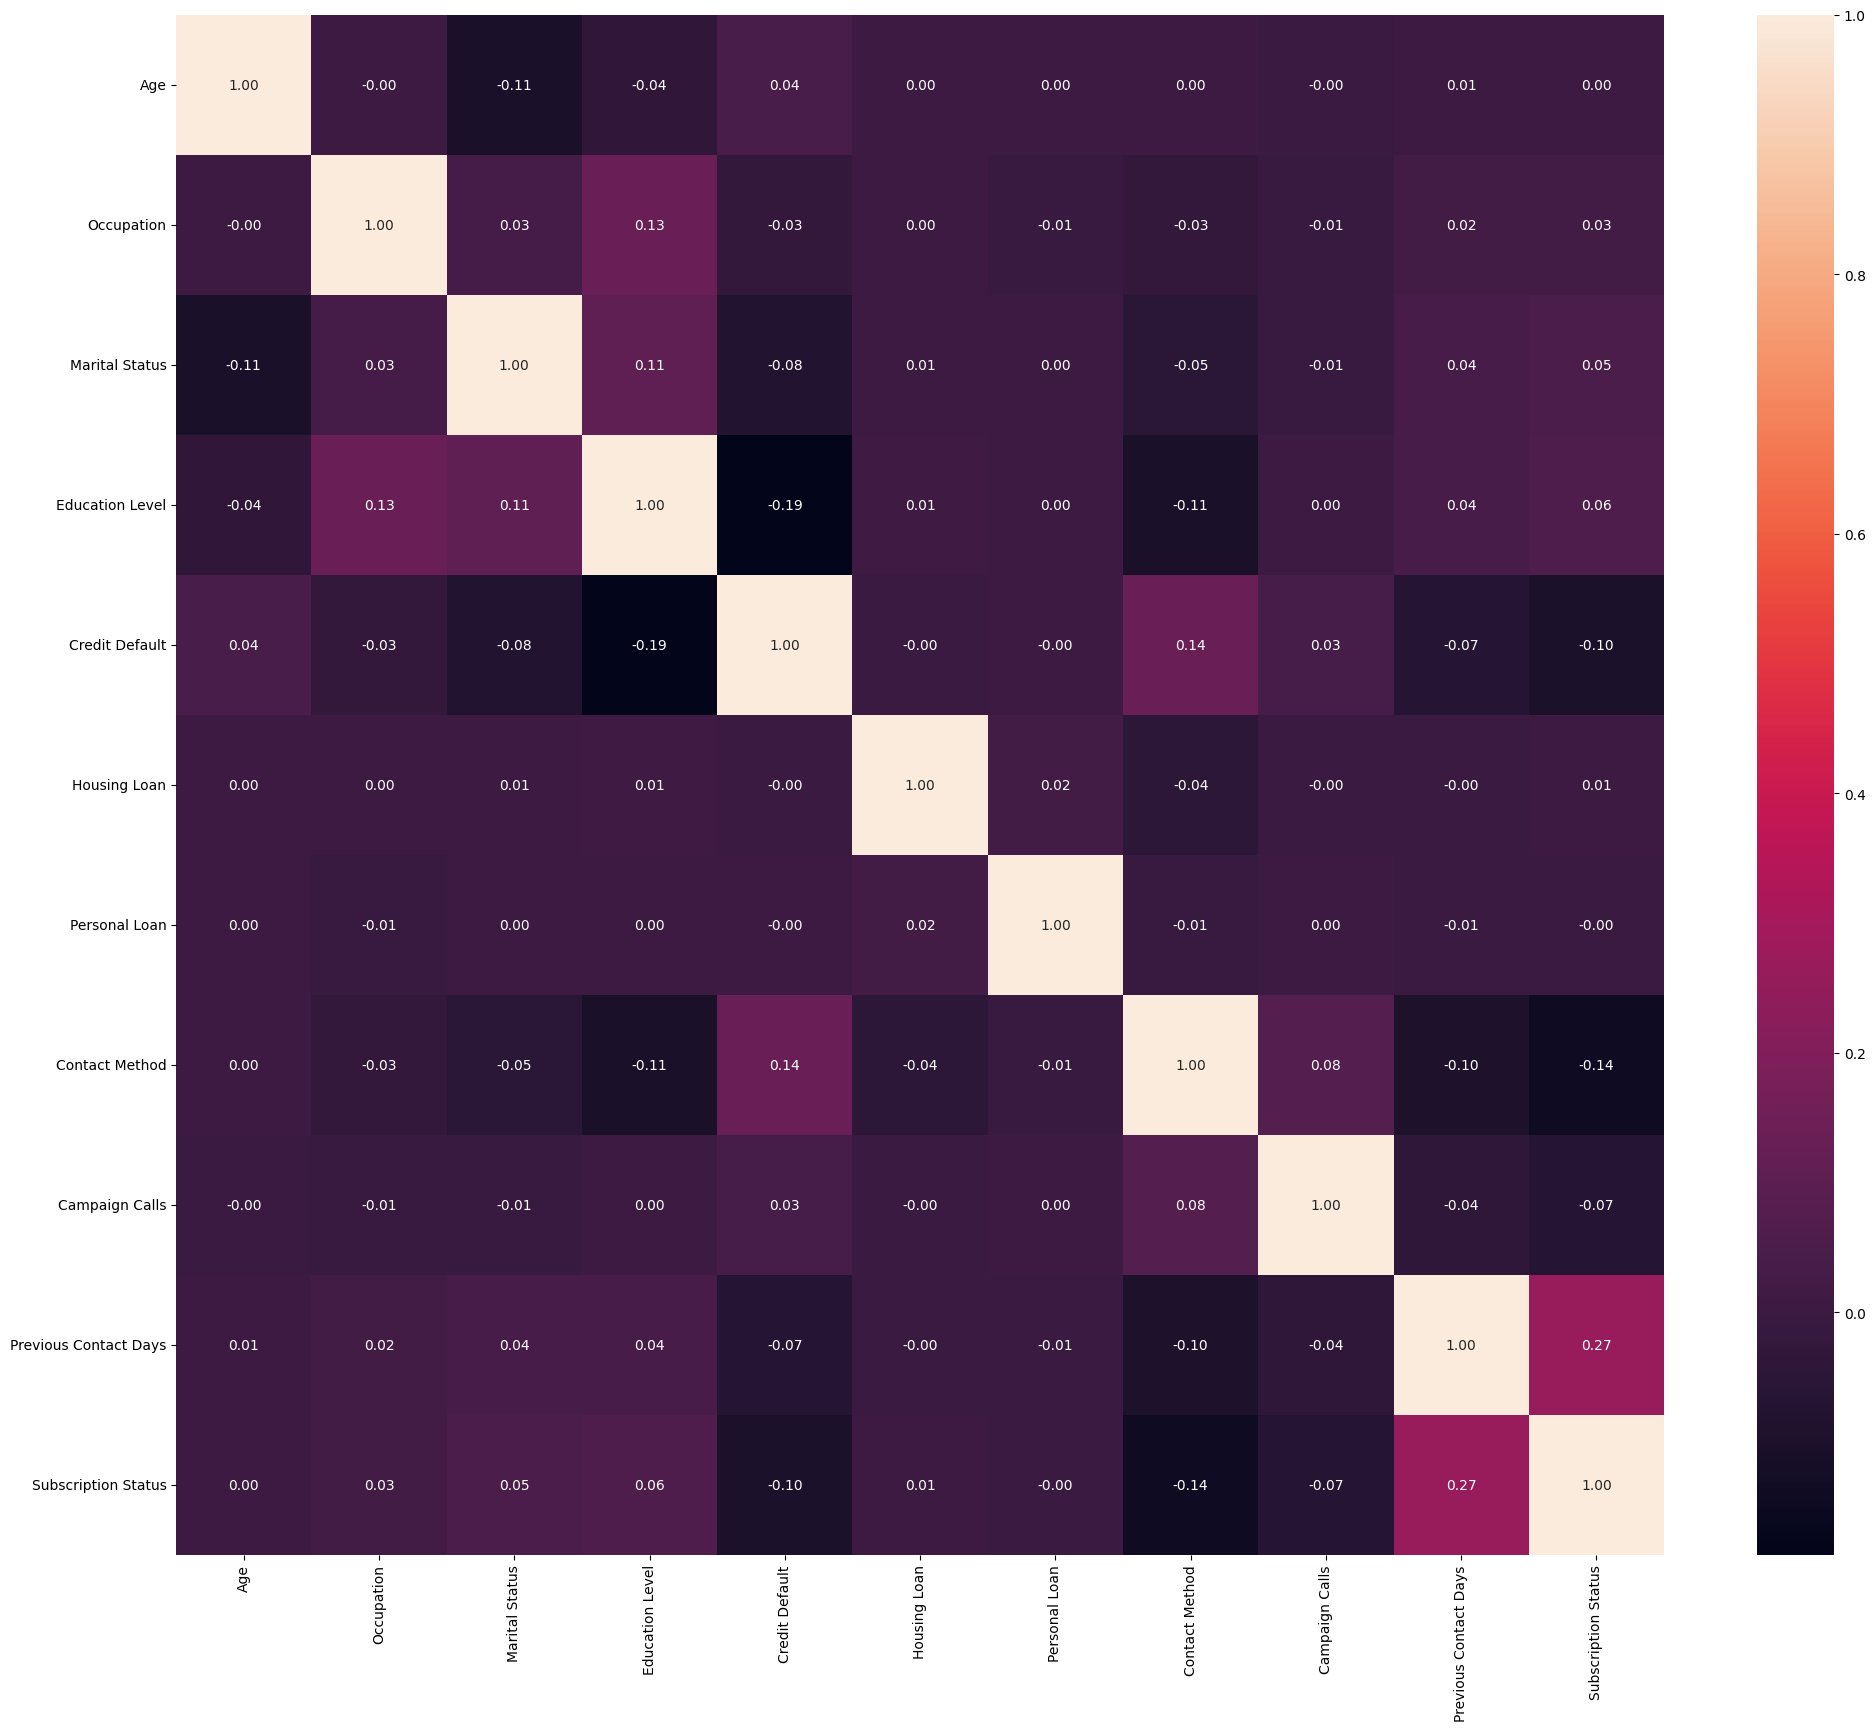

In [82]:
fig, ax = plt.subplots(figsize=(24, 20))
sns.heatmap(df_label_encoded.corr(numeric_only=True), annot=True, fmt=".2f")

One hot encoder below

In [83]:
df_copy_noID = df_drop_dups.copy()
df_copy_noID.drop(columns=["Client ID"], inplace=True)
str_columns = df_copy.select_dtypes(include=['object']).columns.tolist()
df_encoded = pd.get_dummies(df_copy_noID, columns=str_columns, drop_first=True)
df_encoded

,Age,Campaign Calls,Previous Contact Days,Subscription Status,Occupation_blue-collar,Occupation_entrepreneur,Occupation_housemaid,Occupation_management,Occupation_retired,Occupation_self-employed,...,Education Level_professional.course,Education Level_university.degree,Education Level_unknown,Credit Default_unknown,Credit Default_yes,Housing Loan_unknown,Housing Loan_yes,Personal Loan_unknown,Personal Loan_yes,Contact Method_telephone
0,57,1,999,0,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1,55,2,999,0,False,False,False,False,False,False,...,False,False,True,True,False,False,True,False,False,True
2,33,1,999,0,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,36,4,999,0,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,27,2,999,0,False,False,True,False,False,False,...,False,False,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,58,2,999,0,False,False,False,False,True,False,...,True,False,False,True,False,False,False,False,False,True
41184,37,1,999,0,False,False,False,True,False,False,...,False,True,False,False,False,False,False,False,False,True
41185,35,1,4,1,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
41186,40,2,999,0,False,False,False,True,False,False,...,False,True,False,False,False,True,False,False,False,True


## One Hot Encoding for Occupation

In [84]:
df_encoded_occupation = df_encoded.drop(columns=[col for col in df_encoded.columns if 'Occupation_' not in col])
df_encoded_occupation = pd.concat([df_encoded_occupation, df_encoded['Subscription Status']], axis=1)
df_encoded_occupation

,Occupation_blue-collar,Occupation_entrepreneur,Occupation_housemaid,Occupation_management,Occupation_retired,Occupation_self-employed,Occupation_services,Occupation_student,Occupation_technician,Occupation_unemployed,Occupation_unknown,Subscription Status
0,False,False,False,False,False,False,False,False,True,False,False,0
1,False,False,False,False,False,False,False,False,False,False,True,0
2,True,False,False,False,False,False,False,False,False,False,False,0
3,False,False,False,False,False,False,False,False,False,False,False,0
4,False,False,True,False,False,False,False,False,False,False,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...
41183,False,False,False,False,True,False,False,False,False,False,False,0
41184,False,False,False,True,False,False,False,False,False,False,False,0
41185,False,False,False,False,False,False,False,False,False,False,False,1
41186,False,False,False,True,False,False,False,False,False,False,False,0


<Axes: >

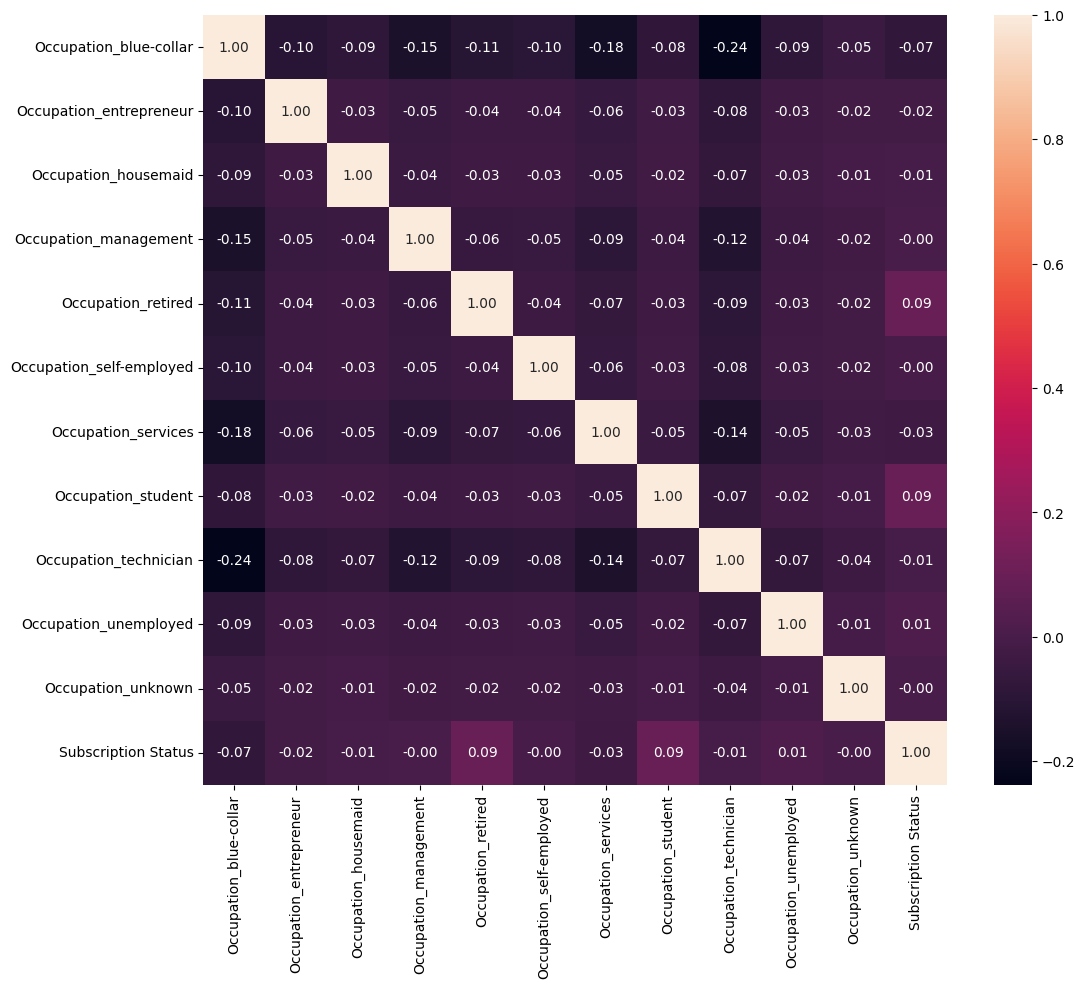

In [85]:
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(df_encoded_occupation.corr(numeric_only=True), annot=True, fmt=".2f")

## One Hot Encoding for Marital Status

In [86]:
df_encoded_marital_status = df_encoded.drop(columns=[col for col in df_encoded.columns if 'Marital Status_' not in col])
df_encoded_marital_status = pd.concat([df_encoded_marital_status, df_encoded['Subscription Status']], axis=1)
df_encoded_marital_status

,Marital Status_married,Marital Status_single,Marital Status_unknown,Subscription Status
0,True,False,False,0
1,True,False,False,0
2,True,False,False,0
3,True,False,False,0
4,True,False,False,0
...,...,...,...,...
41183,True,False,False,0
41184,True,False,False,0
41185,True,False,False,1
41186,True,False,False,0


<Axes: >

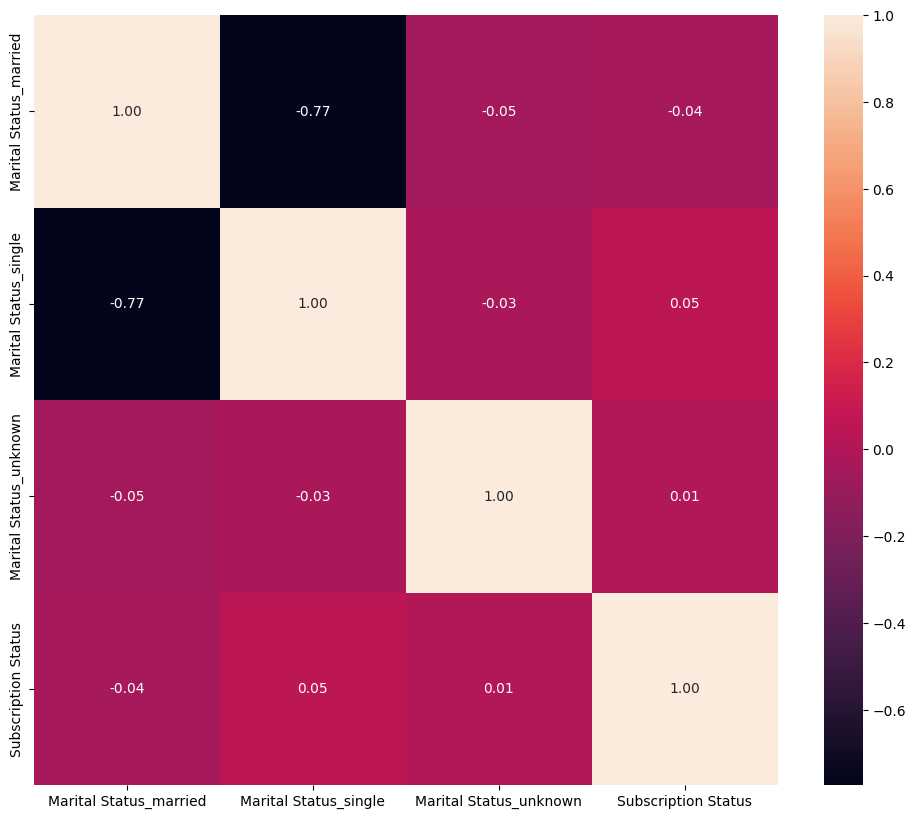

In [87]:
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(df_encoded_marital_status.corr(numeric_only=True), annot=True, fmt=".2f")

## One Hot Encoding for Education Level

In [88]:
df_encoded_education = df_encoded.drop(columns=[col for col in df_encoded.columns if 'Education Level_' not in col])
df_encoded_education = pd.concat([df_encoded_education, df_encoded['Subscription Status']], axis=1)
df_encoded_education

,Education Level_basic.6y,Education Level_basic.9y,Education Level_high.school,Education Level_illiterate,Education Level_professional.course,Education Level_university.degree,Education Level_unknown,Subscription Status
0,False,False,True,False,False,False,False,0
1,False,False,False,False,False,False,True,0
2,False,True,False,False,False,False,False,0
3,False,False,True,False,False,False,False,0
4,False,False,True,False,False,False,False,0
...,...,...,...,...,...,...,...,...
41183,False,False,False,False,True,False,False,0
41184,False,False,False,False,False,True,False,0
41185,False,False,True,False,False,False,False,1
41186,False,False,False,False,False,True,False,0


<Axes: >

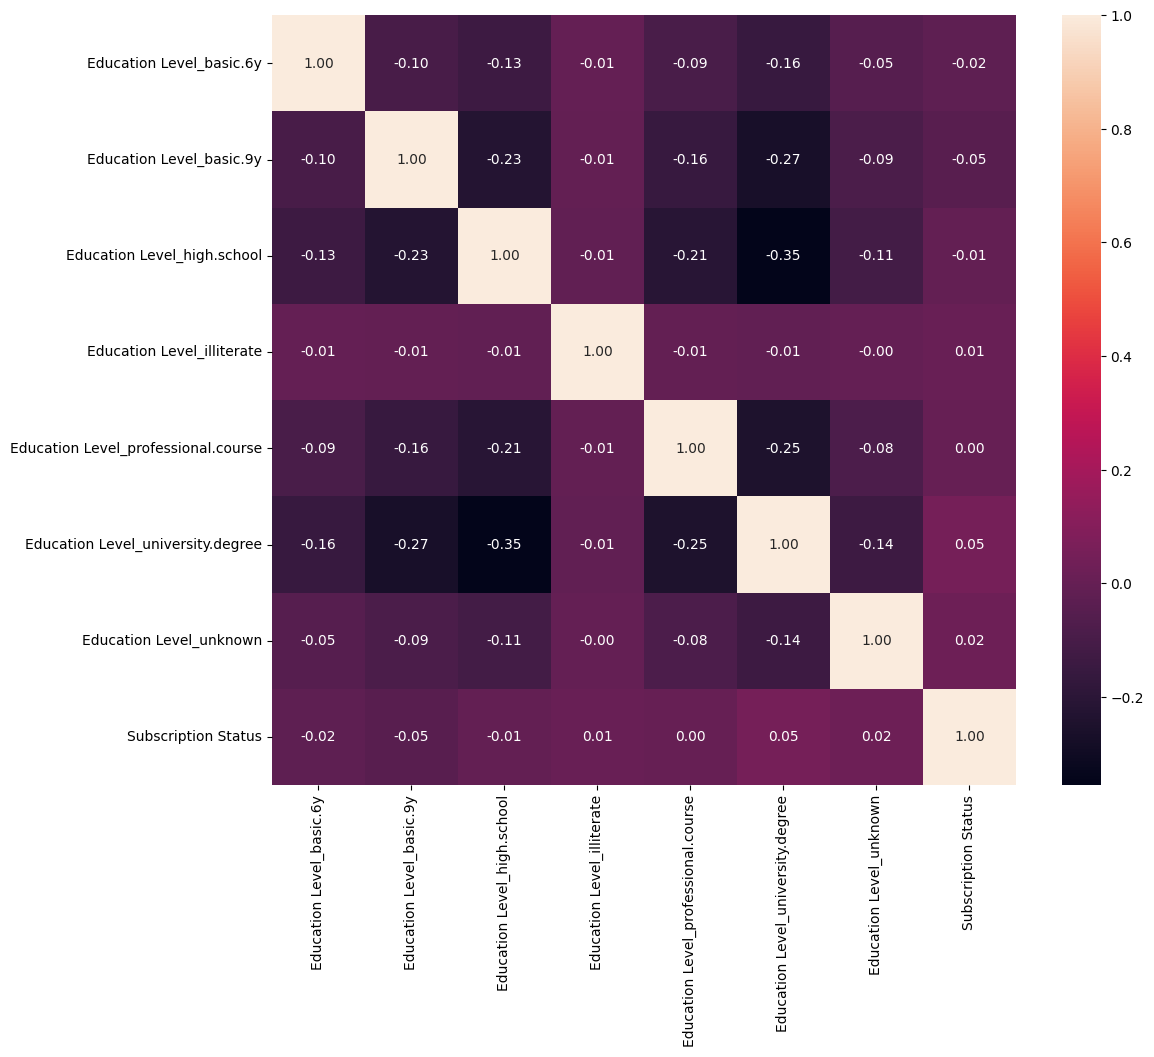

In [89]:
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(df_encoded_education.corr(numeric_only=True), annot=True, fmt=".2f")

## One Hot Encode for Personal Loan

In [90]:
df_encoded_personal_loan = df_encoded.drop(columns=[col for col in df_encoded.columns if 'Personal Loan_' not in col])
df_encoded_personal_loan = pd.concat([df_encoded_personal_loan, df_encoded['Subscription Status']], axis=1)
df_encoded_personal_loan

,Personal Loan_unknown,Personal Loan_yes,Subscription Status
0,False,True,0
1,False,False,0
2,False,False,0
3,False,False,0
4,False,False,0
...,...,...,...
41183,False,False,0
41184,False,False,0
41185,False,False,1
41186,False,False,0


<Axes: >

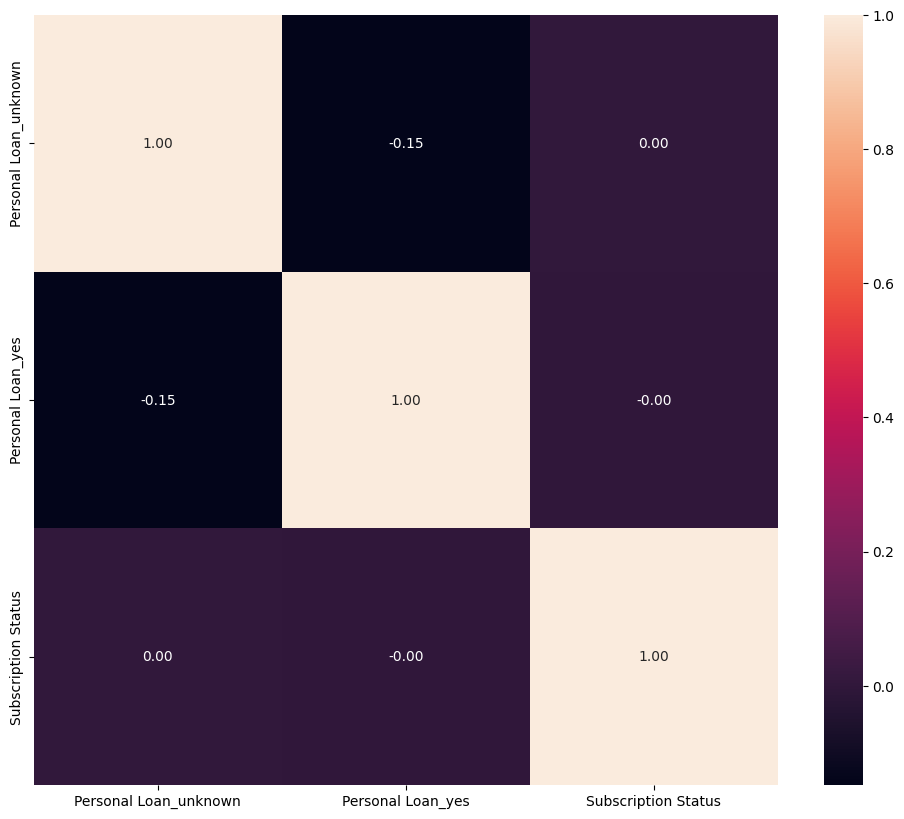

In [91]:
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(df_encoded_personal_loan.corr(numeric_only=True), annot=True, fmt=".2f")

## One Hot Encode Credi Default

In [92]:
df_encoded_credit = df_encoded.drop(columns=[col for col in df_encoded.columns if 'Credit Default_' not in col])
df_encoded_credit = pd.concat([df_encoded_credit, df_encoded['Subscription Status']], axis=1)
df_encoded_credit

,Credit Default_unknown,Credit Default_yes,Subscription Status
0,False,False,0
1,True,False,0
2,False,False,0
3,False,False,0
4,False,False,0
...,...,...,...
41183,True,False,0
41184,False,False,0
41185,False,False,1
41186,False,False,0


<Axes: >

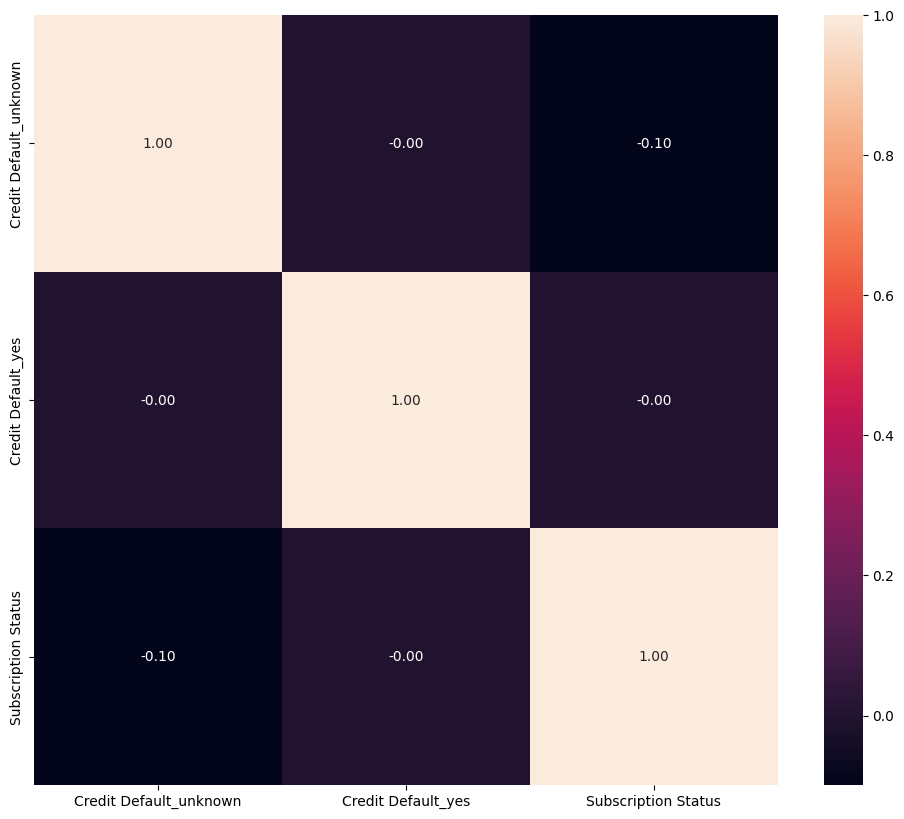

In [93]:
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(df_encoded_credit.corr(numeric_only=True), annot=True, fmt=".2f")

## Others

In [94]:
df_encoded_rest = df_encoded.drop(columns=[col for col in df_encoded.columns if ('Occupation_' in col) or ('Marital Status_' in col) or ('Education Level_' in col) or ('Personal Loan_' in col) or ('Credit Default_' in col)])
df_encoded_rest

,Age,Campaign Calls,Previous Contact Days,Subscription Status,Housing Loan_unknown,Housing Loan_yes,Contact Method_telephone
0,57,1,999,0,False,False,False
1,55,2,999,0,False,True,True
2,33,1,999,0,False,False,False
3,36,4,999,0,False,False,True
4,27,2,999,0,True,False,False
...,...,...,...,...,...,...,...
41183,58,2,999,0,False,False,True
41184,37,1,999,0,False,False,True
41185,35,1,4,1,True,False,False
41186,40,2,999,0,True,False,True


<Axes: >

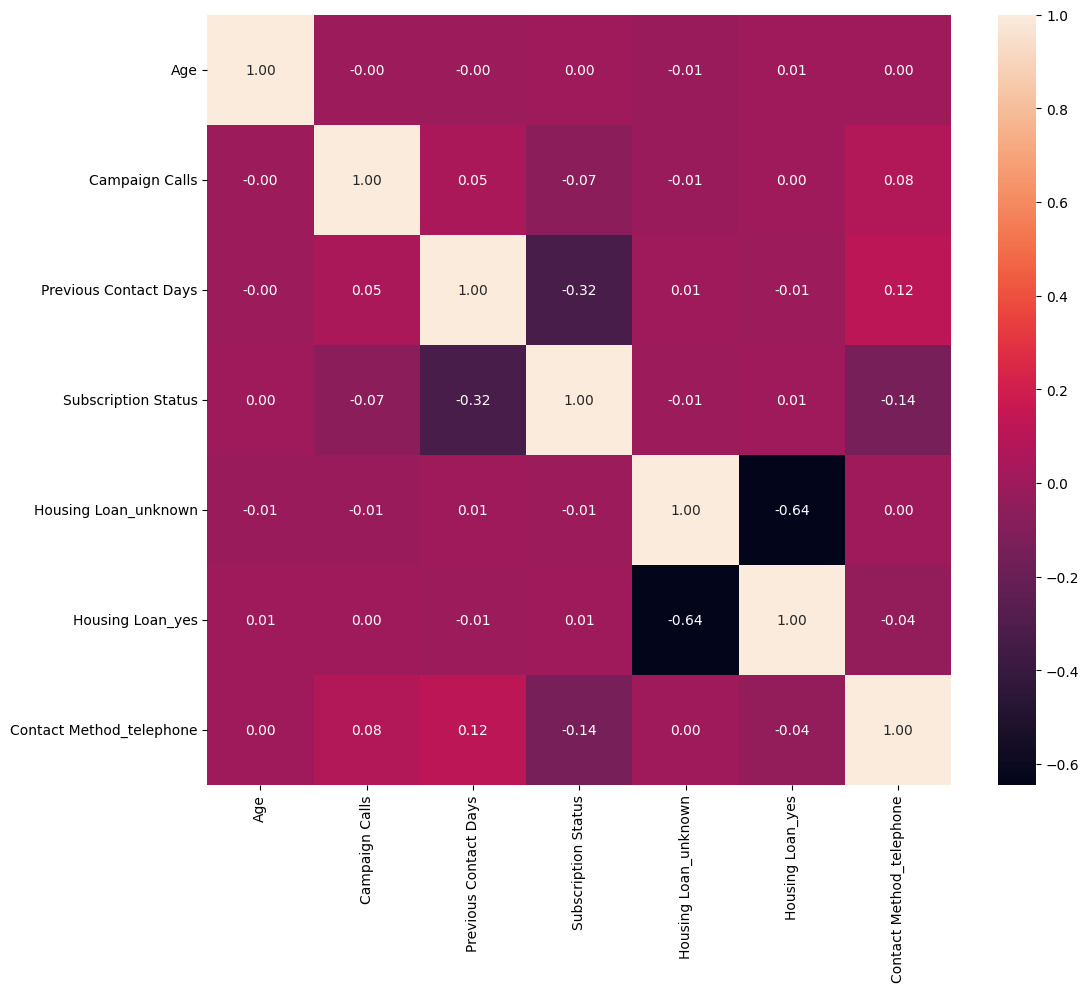

In [95]:
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(df_encoded_rest.corr(numeric_only=True), annot=True, fmt=".2f")

Jade eda

In this project, I focus on four key attributes:
-Age (Numerical and optionally grouped)  -Credit Default (Categorial: yes/no/unknown) -Contact Method (Categorical: cellular/telephone) -Subscription Status (Target: yes/no)

I reuse the cleaned data from 'df_drop_dups' and create a separate DataFrame so that I do not modify my teammate's code

In [96]:
df_eda = df_drop_dups.copy()

df_eda["Subscription Status"] = df_eda["Subscription Status"].replace({"yes": 1, "no": 0}).astype(int)

df_eda["Subscription Status"].value_counts(dropna=False)
df_eda["Subscription Status"].dtype


dtype('int64')

'Age' was previously cleaned from strings like '57 years' into integers. I futher group ages into different stages to easier intrepret which age segments respond best to the term-deposit campaign.

In [97]:
age_bins = [18, 25, 35, 45, 55, 65, 100]
age_labels = ["18–24", "25–34", "35–44", "45–54", "55–64", "65+"]

df_eda["Age Group"] = pd.cut(
    df_eda["Age"],
    bins=age_bins,
    labels=age_labels,
    right=False
)

df_eda[["Age", "Age Group"]].head()

,Age,Age Group
0,57,55–64
1,55,55–64
2,33,25–34
3,36,35–44
4,27,25–34


I compute subscription rate (in %) for each category in a column. Subscription Status is assumed to be 0 (no) / 1 (yes)

In [106]:
def sub_rate(df, col):
    return (
        df.groupby(col)["Subscription Status"]
          .mean()
          .mul(100)  
          .reset_index(name="subscription_rate")
          .sort_values("subscription_rate", ascending=False)
    )

- Credit Default Status

Clients with no credit default have the highest subscription rate (~12.9%).
This indicates that financially reliable customers are more responsive to term-deposit promotions.
Customers with unknown credit status show a significantly lower rate (~5.1%), suggesting uncertainty or lack of trust.
Clients who have defaulted previously (yes) do not subscribe at all (0%).

This behaviour aligns with financial principles: customers with credit risk tend to avoid or be excluded from long-term investment products.
It also creates a sparse class problem, where the "yes" group has very few samples.
This may cause instability during model training and should be handled during predictive modelling
(e.g. class weights, grouping yes with unknown, or removing it).

- Contact Method

The Contact Method attribute shows a very strong impact.

Clients contacted via cellular (mobile phone) subscribe at ~14.7%,
more than double the conversion rate of telephone (landline) at ~5.2%.

This suggests that personal phone calls are much more persuasive and effective than traditional landline contact.
The bank should prioritize mobile contact in future campaigns, as it results in higher customer engagement and conversion.

Contact Method vs Subscription

In [99]:
contact_rate = sub_rate(df_eda, "Contact Method")
contact_rate

,Contact Method,subscription_rate
0,cellular,14.737607
1,telephone,5.231321


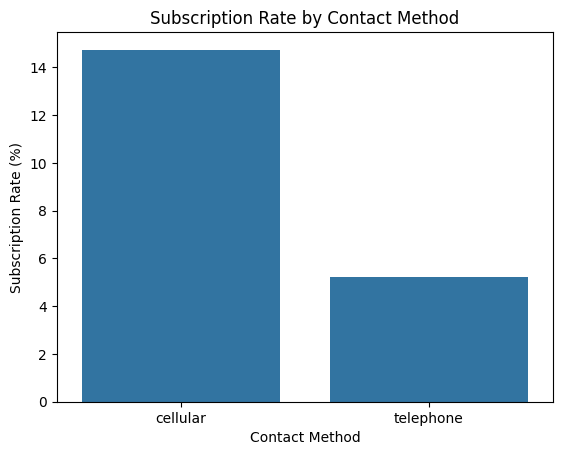

In [100]:
sns.barplot(
    data=contact_rate,
    x="Contact Method",
    y="subscription_rate"
)
plt.ylabel("Subscription Rate (%)")
plt.title("Subscription Rate by Contact Method")
plt.show()

### Subscription Rate by Contact Method

The bar chart shows that clients contacted via **cellular** have a higher
subscription rate than those contacted via **telephone**.

This suggests that personal mobile contact is a more effective channel
for promoting term deposits compared to traditional landline calls.  
From a marketing perspective, AI-Vive-Banking should prioritise cellular
numbers when planning future campaigns.

Credit Default vs Subscription

In [101]:
credit_rate = sub_rate(df_eda, "Credit Default")
credit_rate

,Credit Default,subscription_rate
0,no,12.878974
1,unknown,5.152960
2,yes,0.000000


In [65]:
df_eda["Credit Default"].value_counts()

Credit Default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64

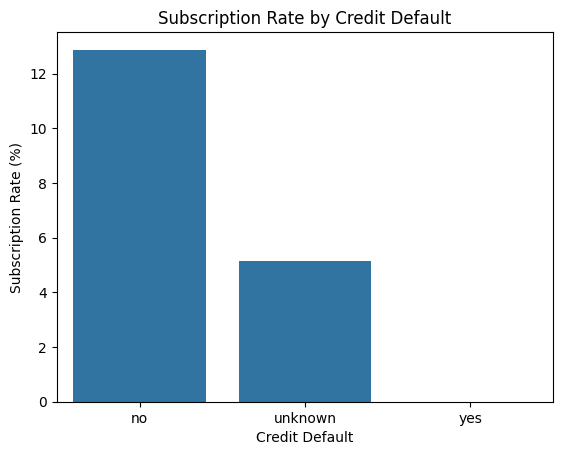

In [59]:
sns.barplot(
    data=credit_rate,
    x="Credit Default",
    y="subscription_rate"
)
plt.ylabel("Subscription Rate (%)")
plt.title("Subscription Rate by Credit Default")
plt.show()

### Subscription Rate by Credit Default

Most clients have `no` credit default, and this group shows the highest
subscription rate.

Clients with `unknown` credit status subscribe less often. The very small
number of `yes` default cases leads to unstable statistics, but they are
generally less likely to subscribe.

This indicates that financially reliable clients are more receptive to
term deposits, while uncertain or risky profiles respond less to the
campaign.

Age Group vs Subscription

In [60]:
age_rate = sub_rate(df_eda, "Age Group")
age_rate

C:\Users\Qxiuj\AppData\Local\Temp\ipykernel_28332\148014637.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(col)["Subscription Status"]


,Age Group,subscription_rate
5,65+,47.920133
0,18–24,23.933403
4,55–64,13.563004
1,25–34,12.253705
2,35–44,8.730420
3,45–54,8.600770


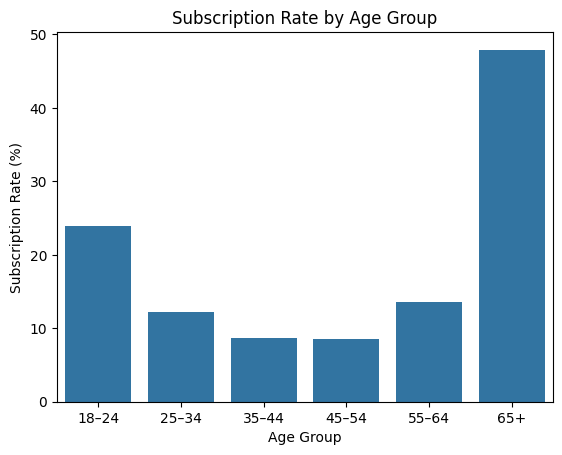

In [61]:
sns.barplot(
    data=age_rate,
    x="Age Group",
    y="subscription_rate"
)
plt.ylabel("Subscription Rate (%)")
plt.title("Subscription Rate by Age Group")
plt.show()

### Subscription Rate by Age Group

The term deposit campaign shows very strong variation across customer age segments.
The 65+ category has the highest conversion rate at 47.9%, meaning almost half of the clients in this age group subscribed. This aligns with typical financial behaviour where senior customers prioritise low-risk and long-term investment products to protect their retirement savings.

Young adults aged 18–24 also demonstrate unexpectedly high interest, with a subscription rate of 23.9%. This indicates that younger clients may be more optimistic and open to long-term savings, especially at the start of their careers.

In contrast, middle-aged customers (35–54) show the lowest conversion rates (~8–9%).
These groups typically face higher financial commitments (mortgages, children, daily expenses) and therefore prefer liquidity or higher-return investment strategies compared to term deposits.

Overall, the results clearly identify two strong target groups:
- Senior clients (65+)
- Young adults (18–24)

These demographic insights can be used to tailor marketing strategies and improve campaign performance.

In [107]:
ohe_df = df_eda[["Age", "Age Group", "Credit Default", "Contact Method", "Subscription Status"]].copy()

ohe_df = pd.get_dummies(
    ohe_df,
    columns=["Age Group", "Credit Default", "Contact Method"],
    drop_first=True
)

ohe_df.head()

,Age,Subscription Status,Age Group_25–34,Age Group_35–44,Age Group_45–54,Age Group_55–64,Age Group_65+,Credit Default_unknown,Credit Default_yes,Contact Method_telephone
0,57,0,False,False,False,True,False,False,False,False
1,55,0,False,False,False,True,False,True,False,True
2,33,0,True,False,False,False,False,False,False,False
3,36,0,False,True,False,False,False,False,False,True
4,27,0,True,False,False,False,False,False,False,False


In [108]:
corr_with_target = (
    ohe_df.corr(numeric_only=True)["Subscription Status"]
          .drop("Subscription Status")
          .sort_values(ascending=False)
)

corr_with_target

Age Group_65+               0.141076
Age Group_55–64             0.021170
Age Group_25–34             0.020375
Age                         0.002641
Credit Default_yes         -0.003041
Age Group_45–54            -0.040703
Age Group_35–44            -0.051803
Credit Default_unknown     -0.099293
Contact Method_telephone   -0.144773
Name: Subscription Status, dtype: float64

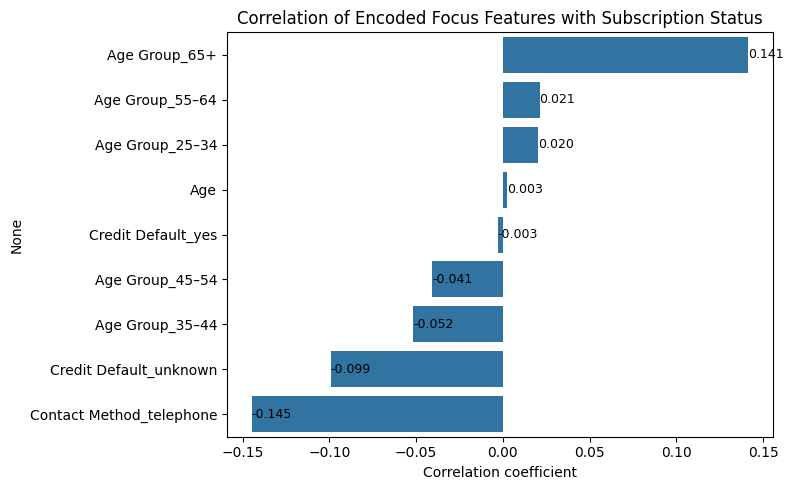

In [64]:
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    x=corr_with_target.values,
    y=corr_with_target.index,
    orient="h"
)
plt.title("Correlation of Encoded Focus Features with Subscription Status")
plt.xlabel("Correlation coefficient")

for p, val in zip(ax.patches, corr_with_target.values):
    ax.annotate(f"{val:.3f}",
                (p.get_width(), p.get_y() + p.get_height()/2),
                ha="left", va="center", fontsize=9)

plt.tight_layout()
plt.show()